## Online Retail Analysis

### Load Dataset

In [4]:
## Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
## Load the dataset
df = pd.read_excel("./Dataset/Online Retail.xlsx")

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
## Some basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
## Basic descriptive statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Data Preprocessing

In [9]:
## Check for duplicate values
df.duplicated().sum()

np.int64(5268)

In [10]:
## Drop duplicate values
df.drop_duplicates(inplace=True)

In [11]:
## Check total no. of null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [12]:
## Percentage of null values contains each column
(df.isnull().sum()/df.shape[0])*100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.270945
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     25.163377
Country         0.000000
dtype: float64

In [13]:
## Remove null values
df.dropna(subset=['Description', 'CustomerID'], inplace=True)

In [14]:
## After removing all null values check percentage of null values in each column
(df.isnull().sum()/df.shape[0])*100

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
dtype: float64

In [15]:
## Remove negative quantity
df = df[df['Quantity'] > 0]

## Remove zero or negative price
df = df[df['UnitPrice'] > 0]


In [16]:
## Shape of the dataset after cleaning
df.shape

(392692, 8)

In [17]:
## Check total no. of unique customer
df['CustomerID'].nunique()

4338

#### Comments:
In our dataset we have **4338** unique customers.

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
(df['InvoiceDate'].max() - df['InvoiceDate'].min())

Timedelta('373 days 04:24:00')

### Feature Creation

In [20]:
## Create Total Price Column
df['Total_Price'] = df['Quantity']*df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
## Last date of purchasing
reference_date = df['InvoiceDate'].max()
reference_date

Timestamp('2011-12-09 12:50:00')

In [22]:
rfm_df = df.groupby(['CustomerID']).aggregate({
    'InvoiceDate' : lambda x:(reference_date-x.max()).days,
    'InvoiceNo' :'count',
    'Total_Price' : 'sum'
})

rfm_df


,InvoiceDate,InvoiceNo,Total_Price
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40
...,...,...,...
18280.0,277,10,180.60
18281.0,180,7,80.82
18282.0,7,12,178.05


In [23]:
# Rename columns
rfm_df.columns = ['Recency', 'Frequency', 'Monetary']
rfm_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


### EDA

In [24]:
for index, i in enumerate(rfm_df.columns):
    print(index, i)

0 Recency
1 Frequency
2 Monetary


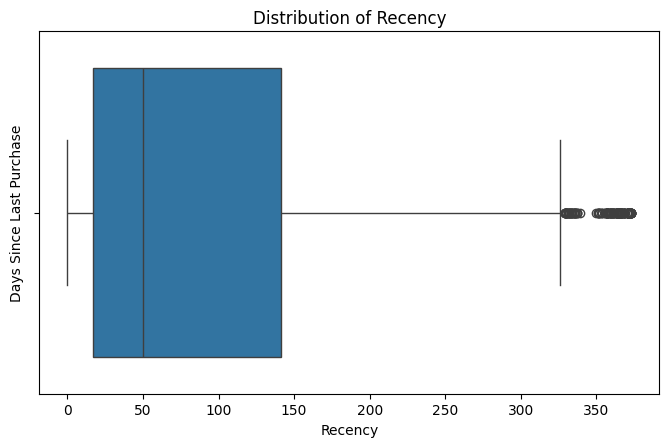

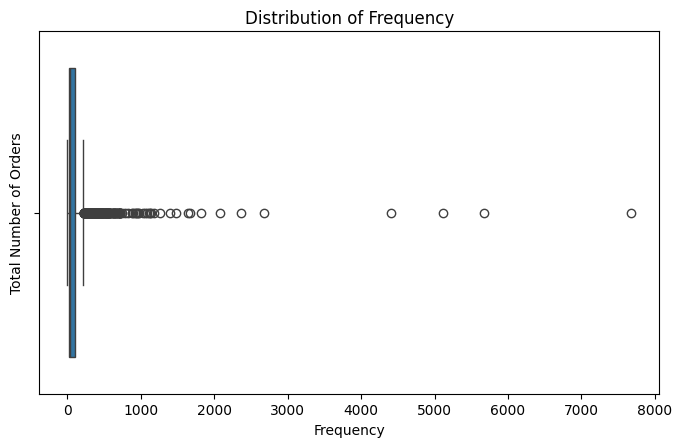

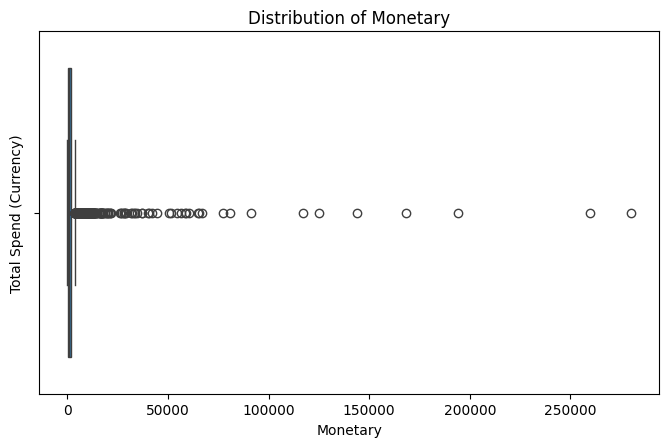

In [25]:
y_label = ["Days Since Last Purchase", "Total Number of Orders", "Total Spend (Currency)"]

for index, i in enumerate(rfm_df.columns):
    plt.figure(figsize=(8,16))
    plt.subplot(3, 1, index+1)

    sns.boxplot(data=rfm_df, x=i)
    plt.xlabel(i)
    plt.ylabel(y_label[index])
    plt.title(f"Distribution of {i}")
    

#### Comments:
From the above analysis we can see that RFM values are highly skewed, so to handle skewness we apply log transformer.

### Feature Transformation

In [26]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer

## Create instantiate
scaler = StandardScaler()
transformer = FunctionTransformer(np.log1p)

In [27]:
rfm_df_transformed = transformer.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])
rfm_df_transformed 

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.786897,0.693147,11.253955
12347.0,0.693147,5.209486,8.368925
12348.0,4.317488,3.465736,7.494564
12349.0,2.944439,4.304065,7.472245
12350.0,5.736572,2.890372,5.815324
...,...,...,...
18280.0,5.627621,2.397895,5.201806
18281.0,5.198497,2.079442,4.404522
18282.0,2.079442,2.564949,5.187665


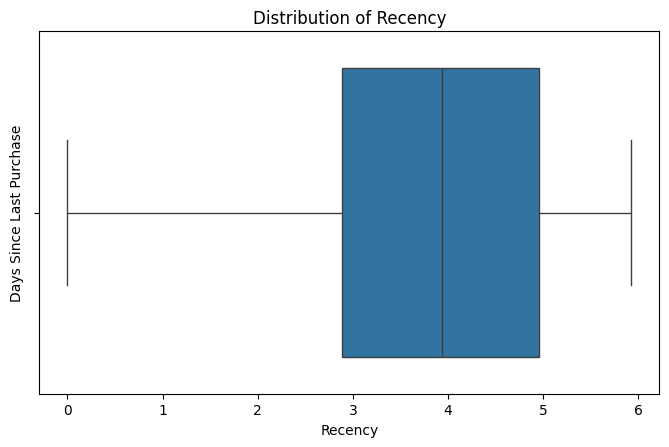

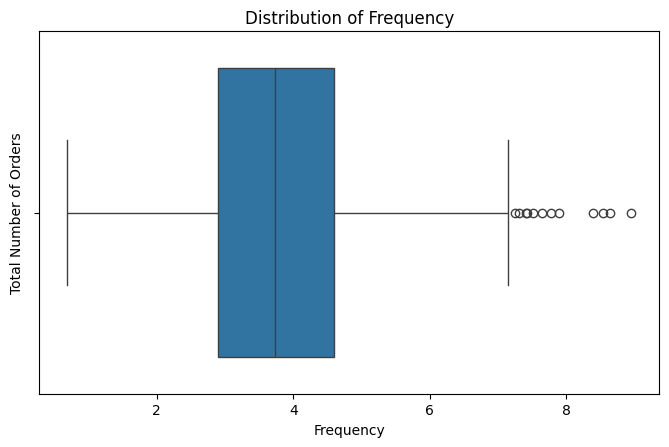

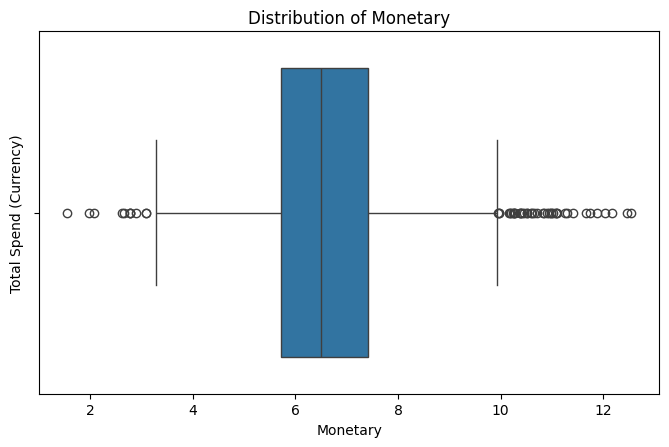

In [28]:
y_label = ["Days Since Last Purchase", "Total Number of Orders", "Total Spend (Currency)"]

## After applying log transformation we get distribution of Recency, Frequency, Monetory
for index, i in enumerate(rfm_df_transformed.columns):
    plt.figure(figsize=(8,16))
    plt.subplot(3, 1, index+1)

    sns.boxplot(data=rfm_df_transformed, x=i)
    plt.xlabel(i)
    plt.ylabel(y_label[index])
    plt.title(f"Distribution of {i}")

In [29]:
## Fixing Recency Direction
rfm_df_transformed['Recency'] = -rfm_df_transformed['Recency']

#### Comments:
✔️ What it does:

It Converts:
```
High Recency (bad) → low value
Low Recency (good) → high value
```

In [30]:
## Scaling
rfm_df_scaled = scaler.fit_transform(rfm_df_transformed[['Recency', 'Frequency', 'Monetary']])
rfm_df_scaled

array([[-1.40989446, -2.43820181,  3.7077163 ],
       [ 2.14649825,  1.18898578,  1.41490344],
       [-0.38397128, -0.21146474,  0.72002428],
       ...,
       [ 1.17860486, -0.9349095 , -1.11333158],
       [ 1.66255156,  2.29130702,  0.82281217],
       [ 0.00442205,  0.42858139,  0.73752572]], shape=(4338, 3))

## K-Means Clustering

### Elbow Method

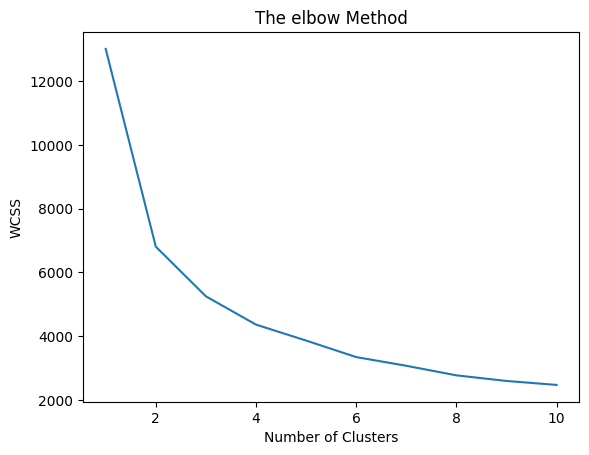

In [31]:
from sklearn.cluster import KMeans
## Within cluster sum of square
## To store Variance with in clusters
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_df_scaled) ## Fit input data

    ## Model output which gives within sum of square
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1,11), y=wcss)
plt.title('The elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS');


In [32]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 7)  ## Silhouette not valid for K=1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_df_scaled)
    
    score = silhouette_score(rfm_df_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3994
K=3, Silhouette Score=0.3068
K=4, Silhouette Score=0.3076
K=5, Silhouette Score=0.2771
K=6, Silhouette Score=0.2732


### K-Means Clustering with k=3

In [33]:
## Model creation
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

labels = kmeans.fit_predict(rfm_df_scaled)

labels

array([1, 2, 1, ..., 0, 2, 1], shape=(4338,), dtype=int32)

In [34]:
rfm_df['Cluster'] = labels
rfm_df

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,1
12347.0,1,182,4310.00,2
12348.0,74,31,1797.24,1
12349.0,18,73,1757.55,1
12350.0,309,17,334.40,0
...,...,...,...,...
18280.0,277,10,180.60,0
18281.0,180,7,80.82,0
18282.0,7,12,178.05,0


In [35]:
rfm_df.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,167.674745,15.229592,296.558840
1,66.853021,66.111051,1197.346697
2,12.177921,265.129689,6669.537781


In [36]:
cluster_map = {
    0: "Churn Risk Customers",
    1: "Regular Customers",
    2: "VIP Customers"
}

rfm_df['Cluster_Label'] = rfm_df['Cluster'].map(cluster_map)
rfm_df

,Recency,Frequency,Monetary,Cluster,Cluster_Label
CustomerID,,,,,
12346.0,325,1,77183.60,1,Regular Customers
12347.0,1,182,4310.00,2,VIP Customers
12348.0,74,31,1797.24,1,Regular Customers
12349.0,18,73,1757.55,1,Regular Customers
12350.0,309,17,334.40,0,Churn Risk Customers
...,...,...,...,...,...
18280.0,277,10,180.60,0,Churn Risk Customers
18281.0,180,7,80.82,0,Churn Risk Customers
18282.0,7,12,178.05,0,Churn Risk Customers


#### Comments:

From the above analysis we can say that **Cluster 2** represents **high-value customers with low recency, high frequency, and high monetary value**, while **Cluster 0** represents **churn-risk customers with low engagement**. **Cluster 1** consists of **regular customers with moderate activity**.

## Hierarchical Clustering

In [37]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import ward, linkage, dendrogram

hierarchical_cls = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_cls

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",3
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [38]:
## Compute the linkage matrix (e.g., using Ward's method)
Z = linkage(rfm_df_scaled, 'ward')
Z

array([[1.37700000e+03, 3.11400000e+03, 8.73423044e-04, 2.00000000e+00],
       [4.89000000e+02, 1.11700000e+03, 4.16650757e-03, 2.00000000e+00],
       [7.70000000e+01, 1.47500000e+03, 4.30509125e-03, 2.00000000e+00],
       ...,
       [8.66400000e+03, 8.67000000e+03, 4.33975789e+01, 2.06000000e+03],
       [8.66900000e+03, 8.67100000e+03, 5.80745851e+01, 2.27800000e+03],
       [8.67200000e+03, 8.67300000e+03, 1.05267180e+02, 4.33800000e+03]],
      shape=(4337, 4))

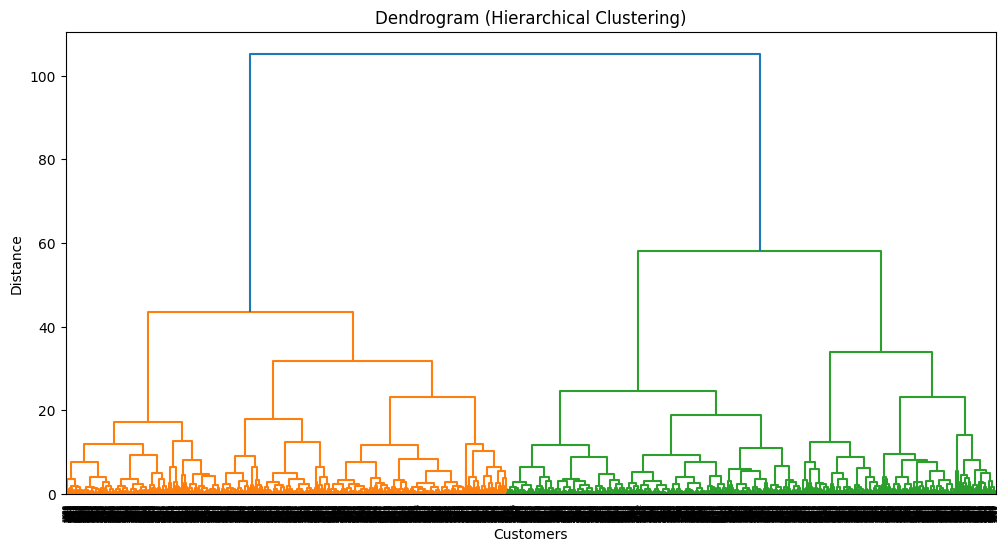

In [39]:
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [40]:
## Prediction
rfm_df['Agg_cluster'] = hierarchical_cls.fit_predict(rfm_df_scaled)
rfm_df

,Recency,Frequency,Monetary,Cluster,Cluster_Label,Agg_cluster
CustomerID,,,,,,
12346.0,325,1,77183.60,1,Regular Customers,0
12347.0,1,182,4310.00,2,VIP Customers,1
12348.0,74,31,1797.24,1,Regular Customers,2
12349.0,18,73,1757.55,1,Regular Customers,2
12350.0,309,17,334.40,0,Churn Risk Customers,0
...,...,...,...,...,...,...
18280.0,277,10,180.60,0,Churn Risk Customers,0
18281.0,180,7,80.82,0,Churn Risk Customers,0
18282.0,7,12,178.05,0,Churn Risk Customers,0


In [41]:
rfm_df.groupby('Agg_cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Agg_cluster,,,
0,139.949029,20.335922,536.214442
1,10.259669,254.459669,6480.385934
2,72.472688,87.774217,1396.837489


In [42]:
cluster_map = {
    0: "Churn Risk Customers",
    2: "Regular Customers",
    1: "VIP Customers"
}

rfm_df['Agg_Cluster_Label'] = rfm_df['Agg_cluster'].map(cluster_map)
rfm_df

,Recency,Frequency,Monetary,Cluster,Cluster_Label,Agg_cluster,Agg_Cluster_Label
CustomerID,,,,,,,
12346.0,325,1,77183.60,1,Regular Customers,0,Churn Risk Customers
12347.0,1,182,4310.00,2,VIP Customers,1,VIP Customers
12348.0,74,31,1797.24,1,Regular Customers,2,Regular Customers
12349.0,18,73,1757.55,1,Regular Customers,2,Regular Customers
12350.0,309,17,334.40,0,Churn Risk Customers,0,Churn Risk Customers
...,...,...,...,...,...,...,...
18280.0,277,10,180.60,0,Churn Risk Customers,0,Churn Risk Customers
18281.0,180,7,80.82,0,Churn Risk Customers,0,Churn Risk Customers
18282.0,7,12,178.05,0,Churn Risk Customers,0,Churn Risk Customers


In [43]:
kmeans_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean(numeric_only=True)
agg_summary = rfm_df.groupby('Agg_cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(kmeans_summary)
print("\n")
print(agg_summary)

            Recency   Frequency     Monetary
Cluster                                     
0        167.674745   15.229592   296.558840
1         66.853021   66.111051  1197.346697
2         12.177921  265.129689  6669.537781


                Recency   Frequency     Monetary
Agg_cluster                                     
0            139.949029   20.335922   536.214442
1             10.259669  254.459669  6480.385934
2             72.472688   87.774217  1396.837489


#### Comments:
### K-Means Clustering
* Churn Risk Customers

In Cluster 0 High Recency, Low Frequency, Low Monetary presents

👉 Interpretation:
Customers who are inactive and low value

* Regular Customers

In Cluster 1, Medium Recency, Medium Frequency, Medium Monetary presents

👉 Interpretation:
Stable, average customers with growth potential

* VIP Customers
In Cluster 2, Very Low Recency, Very High Frequency, Very High Monetary presents

👉 Interpretation:
Top customers driving most revenue

### Hierarchical Clustering
* Churn Risk Customers

In Cluster 0 High Recency, Low Frequency, Low Monetary presents

👉 Interpretation:
Same as KMeans Cluster 0


* VIP Customers
In Cluster 1, Very Low Recency, Very High Frequency, Very High Monetary presents

👉 Interpretation:
Same as KMeans Cluster 2

* Regular Customers

In Cluster 2, Medium Recency, Medium Frequency, Medium Monetary presents

👉 Interpretation:
Same as KMeans Cluster 1


Both K-Means and Agglomerative clustering produced consistent customer segments, confirming that the underlying customer behavior patterns are stable and reliable.

In [44]:
## Create Comparison Table
comparison = pd.crosstab(rfm_df['Cluster'], rfm_df['Agg_cluster'])
print(comparison)

Agg_cluster     0    1     2
Cluster                     
0            1560    0     8
1             493  106  1238
2               7  799   127


#### Comments:
The comparison shows strong agreement between K-Means and Hierarchical clustering for high-value (VIP Customers) and low-value customers (Churn Risk Customers), while moderate overlap exists in the medium segment, which is expected due to gradual behavioral differences.

The consistency in extreme clusters indicates robust segmentation, while the overlap in the middle segment reflects natural ambiguity in customer behavior.

## DBSCAN

In [45]:
from sklearn.cluster import DBSCAN

## Create instantiate of dbscan (density based spatial clustering application with noise)
dbscan = DBSCAN(eps=0.3, min_samples=10)

In [46]:
labels = dbscan.fit_predict(rfm_df_scaled)
labels

array([-1,  0,  0, ..., -1, -1,  0], shape=(4338,))

In [47]:
unique_labels = list(set(labels))
unique_labels


[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)]

In [48]:
from collections import Counter
counts = Counter(labels)
counts

Counter({np.int64(0): 3603,
         np.int64(-1): 677,
         np.int64(1): 21,
         np.int64(3): 20,
         np.int64(2): 17})

In [49]:
rfm_df["dbscan"] = labels
rfm_df

,Recency,Frequency,Monetary,Cluster,Cluster_Label,Agg_cluster,Agg_Cluster_Label,dbscan
CustomerID,,,,,,,,
12346.0,325,1,77183.60,1,Regular Customers,0,Churn Risk Customers,-1
12347.0,1,182,4310.00,2,VIP Customers,1,VIP Customers,0
12348.0,74,31,1797.24,1,Regular Customers,2,Regular Customers,0
12349.0,18,73,1757.55,1,Regular Customers,2,Regular Customers,0
12350.0,309,17,334.40,0,Churn Risk Customers,0,Churn Risk Customers,0
...,...,...,...,...,...,...,...,...
18280.0,277,10,180.60,0,Churn Risk Customers,0,Churn Risk Customers,0
18281.0,180,7,80.82,0,Churn Risk Customers,0,Churn Risk Customers,0
18282.0,7,12,178.05,0,Churn Risk Customers,0,Churn Risk Customers,-1


In [50]:
rfm_df.groupby('dbscan')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
dbscan,,,
-1,62.940916,200.174298,6948.089719
0,96.989176,69.664724,1128.658197
1,0.000000,213.095238,4011.746667
2,295.411765,1.000000,86.365882
3,0.000000,84.000000,1554.088500


#### Comments:
### DBSCAN
* Cluster 2 → Extreme Low-Value / Dead Customers\
&emsp;Recency = VERY HIGH (~295)\
&emsp;Frequency = VERY LOW (1)\
&emsp;Monetary = VERY LOW (~86)

👉 Interpretation:

> Cluster 2 is almost inactive / one-time customers, Bought once long ago and Never returned

* Cluster -1 (Noise) → Super VIP / Outliers\
&emsp;Frequency = VERY HIGH (~200)\
&emsp;Monetary = EXTREMELY HIGH (~6948)\
&emsp;Recency = Medium (~63)

👉 Interpretation:

>High-value but irregular customers\
>Spend a lot\
>Purchase frequently\
>But not always recent

These are important customers DBSCAN isolated

* Cluster 1 → Highly Active VIP Customers\
&emsp;Recency = 0 → very recent\
&emsp;Frequency = VERY HIGH (~213)\
&emsp;Monetary = HIGH (~4011)

👉 Interpretation:

>Core VIP customers\
>Very active\
>Very loyal\
>Consistent buyers
* Cluster 3 → Recent Regular Customers\
&emsp;Recency = 0 → very recent\
&emsp;Frequency = Medium (~84)\
&emsp;Monetary = Medium (~1554)

👉 Interpretation:

>Active but not top-tier customers\
>Recently engaged\
>Moderate spend
* Cluster 0 → Average Customers\
&emsp;Recency = ~97\
&emsp;Frequency = ~69\
&emsp;Monetary = ~1128

👉 Interpretation:

>Typical customers\
>Moderate engagement\
>Not extreme

In [51]:
cluster_map = {
    -1: "High-Value Outliers" ,
    0: "Average Customers",
    1: "Core VIP Customers",
    3: "Active Regular Customers",
    2: "Churned / Inactive Customers"
}

rfm_df['dbscan_label'] = rfm_df['dbscan'].map(cluster_map)
rfm_df

,Recency,Frequency,Monetary,Cluster,Cluster_Label,Agg_cluster,Agg_Cluster_Label,dbscan,dbscan_label
CustomerID,,,,,,,,,
12346.0,325,1,77183.60,1,Regular Customers,0,Churn Risk Customers,-1,High-Value Outliers
12347.0,1,182,4310.00,2,VIP Customers,1,VIP Customers,0,Average Customers
12348.0,74,31,1797.24,1,Regular Customers,2,Regular Customers,0,Average Customers
12349.0,18,73,1757.55,1,Regular Customers,2,Regular Customers,0,Average Customers
12350.0,309,17,334.40,0,Churn Risk Customers,0,Churn Risk Customers,0,Average Customers
...,...,...,...,...,...,...,...,...,...
18280.0,277,10,180.60,0,Churn Risk Customers,0,Churn Risk Customers,0,Average Customers
18281.0,180,7,80.82,0,Churn Risk Customers,0,Churn Risk Customers,0,Average Customers
18282.0,7,12,178.05,0,Churn Risk Customers,0,Churn Risk Customers,-1,High-Value Outliers


#### Key Insights from Customer Segmentation Analysis
1. Clear Customer Segmentation Exists

The analysis consistently identified three major customer groups:

High-value (VIP customers)\
Medium-value (regular customers)\
Low-value (churn-risk customers)

👉 This pattern appeared in both K-Means and Hierarchical clustering, confirming that:\
* **Customer behavior is naturally segmented and stable**

2. Small Group of Customers Drives Most Revenue


Customers in the VIP segment show:\
Very high frequency\
Very high monetary value

👉 This indicates:

**A small percentage of customers contributes disproportionately to total revenue**

3. Presence of High Churn-Risk Customers


A significant group has:\
High recency (not recent)\
Low frequency\
Low spending

👉 Insight:

* **Many customers are inactive and at risk of churn**

* **These customers require re-engagement strategies**

4. Medium Segment Represents Growth Opportunity
Moderate values across RFM

👉 Insight:

* **These customers are neither loyal nor lost**\

* **They are the best target for upselling and conversion into VIPs**

5. DBSCAN Revealed Hidden Customer Behavior


Unlike K-Means:

DBSCAN identified:
High-value outliers (very high spenders)\
Extremely inactive customers

👉 Insight:

* **Traditional clustering misses extreme behaviors**\

* **DBSCAN helps uncover niche and anomalous customer groups**

6. Customer Behavior is Not Uniform


DBSCAN results show:\
One large general group\
Several small specialized clusters\
Significant noise (outliers)

👉 Insight:

* **Customer behavior varies widely and includes extreme cases**\

* **A single clustering approach is not sufficient**\

7. Segmentation is Robust Across Algorithms


K-Means and Hierarchical produced similar segments\
DBSCAN added deeper granularity

👉 Insight:

* **The segmentation is reliable and not dependent on one algorithm**

* **Results are trustworthy for business decisions**

8. Different Models Serve Different Purposes


|Model	                     |           Strength|
| ------------------------   | ------------------- |
|K-Means	                 |      Clear segmentation|\
|Hierarchical	             |          Validation|\
|DBSCAN	                     |      Outlier detection|\

👉 Insight:

Combining models provides a complete understanding of customer behavior
#### Final Insight 

The analysis reveals that customer behavior is highly segmented, with a small group of high-value customers driving revenue, while a significant portion remains inactive or low-value. Combining multiple clustering techniques provides both broad segmentation and deep insights into extreme customer behaviors.

### Define Business Actions

| Segment  | Action                           |
| -------- | -------------------------------- |
| VIP      | Loyalty rewards, premium service |
| Active   | Upselling                        |
| Average  | Engagement campaigns             |
| Churn    | Discounts, reactivation          |
| Outliers | Special targeting                |


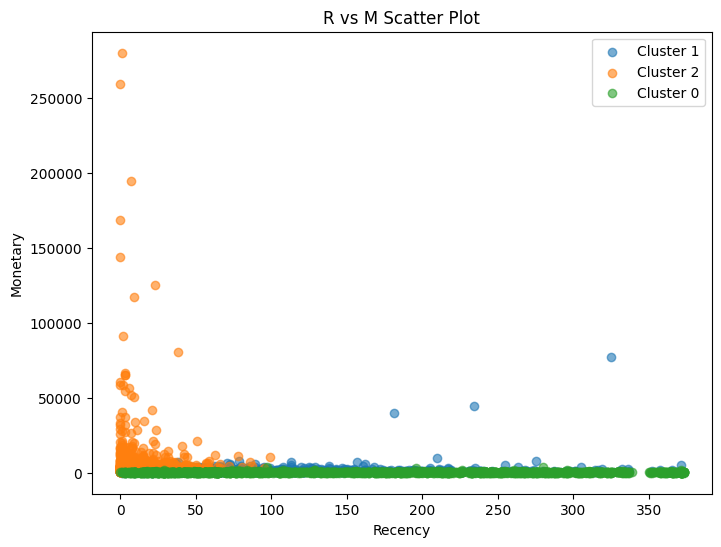

In [55]:
plt.figure(figsize=(8,6))

for cluster in rfm_df['Cluster'].unique():
    subset = rfm_df[rfm_df['Cluster'] == cluster]
    
    plt.scatter(
        subset['Recency'], 
        subset['Monetary'], 
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("R vs M Scatter Plot")
plt.legend()

plt.show()

#### Comments:
A scatter plot of Recency vs Monetary are use to visually analyze customer segments, where high-value customers were clearly separated from low-value and churn-risk customers.

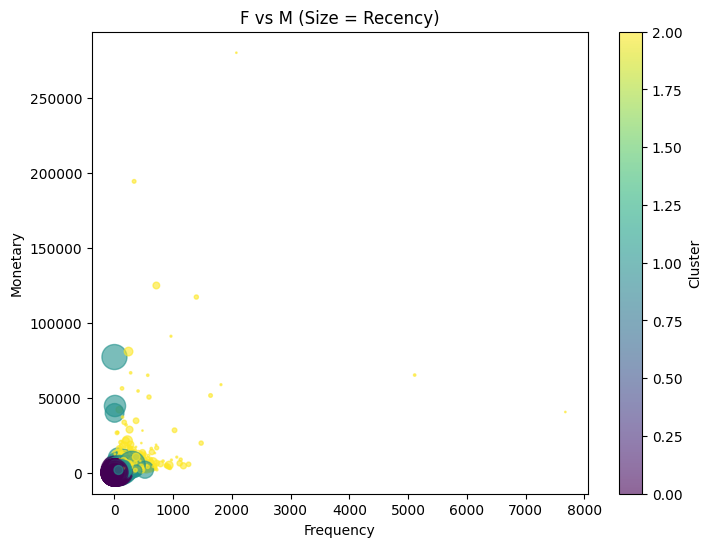

In [56]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm_df['Frequency'],
    rfm_df['Monetary'],
    s=rfm_df['Recency'],   # size = recency
    c=rfm_df['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("F vs M (Size = Recency)")
plt.colorbar(label='Cluster')

plt.show()

#### Conclusion:
Performed RFM-based customer segmentation using K-Means, Hierarchical, and DBSCAN clustering, identifying high-value, regular, and churn-risk customers, along with outliers. The analysis enabled actionable insights for targeted marketing and customer retention strategies.